In [2]:
%pip install -q --no-cache-dir numpy==2.0.2 pandas==2.2.2

%pip install -q --no-cache-dir \
  torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
  --index-url https://download.pytorch.org/whl/cu121

%pip install -q --no-cache-dir torch-geometric

%pip install -q --no-cache-dir \
  pyg-lib -f https://data.pyg.org/whl/torch-2.3.0+cu121.html

%pip install -q --no-cache-dir xgboost catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 169.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 222.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 152.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 222.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 277.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 108.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 180.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 203.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 198.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 256.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 190.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 138.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
from pathlib import Path
import json
import joblib
import numpy as np
import torch
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix, classification_report

In [3]:
SAVE_DIR = Path("/content/drive/MyDrive/saved_models/full_pipeline")
print("Loading artifacts from:", SAVE_DIR)

Loading artifacts from: /content/drive/MyDrive/saved_models/full_pipeline


In [4]:
with open(SAVE_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

loaded_cb = CatBoostClassifier()
loaded_cb.load_model(str(SAVE_DIR / "catboost_model.cbm"))

loaded_iso = joblib.load(SAVE_DIR / "isotonic_calibrator.pkl")
loaded_H_final = np.load(SAVE_DIR / "H_final_embeddings.npy")

print("Artifacts loaded.")
print(metadata)
print("loaded_H_final shape:", loaded_H_final.shape)

Artifacts loaded.
{'final_feature_set_name': 'raw_amounts + currencies + payment_format + time_basic + time_cyclical', 'final_feature_cols': ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format', 'tx_dow', 'tx_is_weekend', 'tx_hour_sin', 'tx_hour_cos'], 'expanded_feature_names_final': ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency__US Dollar', 'Receiving Currency__Bitcoin', 'Receiving Currency__Euro', 'Receiving Currency__Australian Dollar', 'Receiving Currency__Yuan', 'Receiving Currency__Rupee', 'Receiving Currency__Mexican Peso', 'Receiving Currency__Yen', 'Receiving Currency__UK Pound', 'Receiving Currency__Ruble', 'Receiving Currency__Canadian Dollar', 'Receiving Currency__Swiss Franc', 'Receiving Currency__Brazil Real', 'Receiving Currency__Saudi Riyal', 'Receiving Currency__Shekel', 'Payment Currency__US Dollar', 'Payment Currency__Bitcoin', 'Payment Currency__Euro', 'Payment Currency__

In [5]:
def build_catboost_Xy(edge_ids, edge_index, edge_attr_t, y_edge_t, H):
    if hasattr(edge_ids, "detach"):
        edge_ids_np = edge_ids.detach().cpu().numpy()
    else:
        edge_ids_np = np.asarray(edge_ids)

    src = edge_index[0, edge_ids_np].detach().cpu().numpy()
    dst = edge_index[1, edge_ids_np].detach().cpu().numpy()

    hs = H[src]
    hd = H[dst]
    diff = np.abs(hs - hd)
    had = hs * hd
    eattr = edge_attr_t[edge_ids_np].detach().cpu().numpy()

    X = np.concatenate([hs, hd, diff, had, eattr], axis=1)
    y = y_edge_t[edge_ids_np].detach().cpu().numpy()
    return X, y

In [6]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/dataset/HI-Small_Trans.csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist()[:20])
df.head()

(5078345, 11)
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [7]:
ts_cat = pd.to_datetime(df["Timestamp"], errors="coerce")
if ts_cat.isna().any():
    ts_cat = ts_cat.fillna(ts_cat.dropna().min())

order_cat = np.argsort(ts_cat.values.astype("datetime64[ns]"))
E_cat = len(order_cat)

cut_train_cat = int(0.70 * E_cat)
cut_val_cat   = int(0.80 * E_cat)

train_ids_cat = order_cat[:cut_train_cat]
val_ids       = order_cat[cut_train_cat:cut_val_cat]
test_ids      = order_cat[cut_val_cat:]

print("Temporal split sizes ->",
      "train:", len(train_ids_cat),
      "val:", len(val_ids),
      "test:", len(test_ids))

Temporal split sizes -> train: 3554841 val: 507835 test: 1015669


In [8]:
edge_index = torch.tensor(np.load(SAVE_DIR / "edge_index.npy"), dtype=torch.long)
edge_attr_t = torch.tensor(np.load(SAVE_DIR / "edge_attr_t.npy"), dtype=torch.float32)
y_edge_t = torch.tensor(np.load(SAVE_DIR / "y_edge_t.npy"), dtype=torch.float32)

In [9]:
for name in [
    "edge_index", "edge_attr_t", "y_edge_t",
    "val_ids", "test_ids",
    "loaded_H_final", "loaded_cb", "loaded_iso",
    "build_catboost_Xy"
]:
    print(name, "->", name in globals())

edge_index -> True
edge_attr_t -> True
y_edge_t -> True
val_ids -> True
test_ids -> True
loaded_H_final -> True
loaded_cb -> True
loaded_iso -> True
build_catboost_Xy -> True


In [10]:
val_ids = np.load(SAVE_DIR / "val_ids.npy")
test_ids = np.load(SAVE_DIR / "test_ids.npy")

print("Loaded val/test ids:", len(val_ids), len(test_ids))
print("Max val id :", val_ids.max())
print("Max test id:", test_ids.max())
print("Num edges   :", edge_index.shape[1])

Loaded val/test ids: 507833 1015668
Max val id : 4069296
Max test id: 5078335
Num edges   : 5078336


In [11]:
# To make sure ids are clean integer arrays and strictly within edge bounds
num_edges = edge_index.shape[1]

val_ids = np.asarray(val_ids).astype(np.int64).ravel()
test_ids = np.asarray(test_ids).astype(np.int64).ravel()

val_ids = val_ids[(val_ids >= 0) & (val_ids < num_edges)]
test_ids = test_ids[(test_ids >= 0) & (test_ids < num_edges)]

print("After bounds check:")
print("val size :", len(val_ids), "| max:", val_ids.max())
print("test size:", len(test_ids), "| max:", test_ids.max())
print("num_edges:", num_edges)

X_val_cb, y_val_cb = build_catboost_Xy(
    val_ids, edge_index, edge_attr_t, y_edge_t, loaded_H_final
)

X_test_cb, y_test_cb = build_catboost_Xy(
    test_ids, edge_index, edge_attr_t, y_edge_t, loaded_H_final
)

print("X_val_cb shape :", X_val_cb.shape)
print("X_test_cb shape:", X_test_cb.shape)
print("y_val_cb shape :", y_val_cb.shape)
print("y_test_cb shape:", y_test_cb.shape)

After bounds check:
val size : 507833 | max: 4069296
test size: 1015668 | max: 5078335
num_edges: 5078336
X_val_cb shape : (507833, 562)
X_test_cb shape: (1015668, 562)
y_val_cb shape : (507833,)
y_test_cb shape: (1015668,)


In [12]:
num_edges = edge_index.shape[1]

bad_val = np.asarray(val_ids)[np.asarray(val_ids) >= num_edges]
bad_test = np.asarray(test_ids)[np.asarray(test_ids) >= num_edges]

print("bad val ids :", bad_val[:10], "count =", len(bad_val))
print("bad test ids:", bad_test[:10], "count =", len(bad_test))
print("num_edges   :", num_edges)

bad val ids : [] count = 0
bad test ids: [] count = 0
num_edges   : 5078336


In [13]:
p_val_raw = loaded_cb.predict_proba(X_val_cb)[:, 1]
p_test_raw = loaded_cb.predict_proba(X_test_cb)[:, 1]

final_threshold = 0.5
final_test_pred = (p_test_raw >= final_threshold).astype(int)
final_test_cm = confusion_matrix(y_test_cb, final_test_pred, labels=[0, 1])

print("Test confusion matrix:")
print(final_test_cm)

Test confusion matrix:
[[1004253    9617]
 [    273    1525]]


In [14]:
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix, classification_report

cat_metrics = {
    "model": "GNN_plus_CatBoost",
    "feature_set": metadata["final_feature_set_name"],
    "catboost_split": "temporal_70_10_20",
    "val_pos_rate": float(y_val_cb.mean()),
    "val_pr_auc": average_precision_score(y_val_cb, p_val_raw),
    "val_roc_auc": roc_auc_score(y_val_cb, p_val_raw),
    "test_pos_rate": float(y_test_cb.mean()),
    "test_pr_auc": average_precision_score(y_test_cb, p_test_raw),
    "test_roc_auc": roc_auc_score(y_test_cb, p_test_raw),
}

print(cat_metrics)
print("\nTest confusion matrix:")
print(final_test_cm)

print("\nTest classification report:")
print(classification_report(y_test_cb, final_test_pred, digits=4))

{'model': 'GNN_plus_CatBoost', 'feature_set': 'raw_amounts + currencies + payment_format + time_basic + time_cyclical', 'catboost_split': 'temporal_70_10_20', 'val_pos_rate': 0.0010298661654815078, 'val_pr_auc': np.float64(0.5097878216702679), 'val_roc_auc': np.float64(0.9862334881998414), 'test_pos_rate': 0.0017702635377645493, 'test_pr_auc': np.float64(0.6658667838011654), 'test_roc_auc': np.float64(0.9892756784862259)}

Test confusion matrix:
[[1004253    9617]
 [    273    1525]]

Test classification report:
              precision    recall  f1-score   support

         0.0     0.9997    0.9905    0.9951   1013870
         1.0     0.1369    0.8482    0.2357      1798

    accuracy                         0.9903   1015668
   macro avg     0.5683    0.9193    0.6154   1015668
weighted avg     0.9982    0.9903    0.9938   1015668



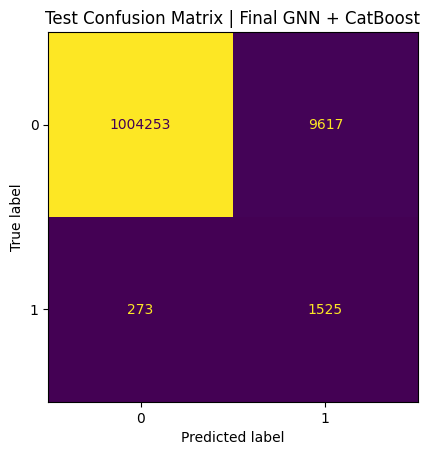

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=final_test_cm, display_labels=[0, 1]).plot(
    values_format="d",
    colorbar=False
)
plt.title("Test Confusion Matrix | Final GNN + CatBoost")
plt.show()

In [16]:
final_model_summary = pd.DataFrame([
    {
        "model": cat_metrics["model"],
        "feature_set": cat_metrics["feature_set"],
        "val_pr_auc": cat_metrics["val_pr_auc"],
        "val_roc_auc": cat_metrics["val_roc_auc"],
        "test_pr_auc": cat_metrics["test_pr_auc"],
        "test_roc_auc": cat_metrics["test_roc_auc"],
    }
])

final_model_summary

,model,feature_set,val_pr_auc,val_roc_auc,test_pr_auc,test_roc_auc
0,GNN_plus_CatBoost,raw_amounts + currencies + payment_format + ti...,0.509788,0.986233,0.665867,0.989276
